In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Find the project root that contains the src folder
current = Path.cwd().resolve()

for p in [current] + list(current.parents):
    if (p / "src").exists():
        repo_root = p
        break
else:
    raise FileNotFoundError("Could not find a folder containing 'src'.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Current working directory:", current)
print("Added repo root:", repo_root)
print("src exists:", (repo_root / "src").exists())

from pathlib import Path
import numpy as np
import pandas as pd

import src.utils.pdata_io as pdio
from src.proc.extract_epoch_windows import load_epoch_windows

data_root, pdata_root, cc_data = pdio.load_project_context()

windows_df = load_epoch_windows(
    pdata_root=pdata_root,
    filename="behavior_epoch_windows.h5",
    key="windows/prepost_1s"
)

valid_windows = windows_df[windows_df["valid_window"]].copy()

print("All windows:", windows_df.shape)
print("Valid windows:", valid_windows.shape)

valid_windows.groupby(["phase", "epoch_name"]).size().reset_index(name="n_windows")

encoder_epoch_df = pd.read_hdf(
    Path(pdata_root) / "_cache" / "behavior_epoch_metrics.h5",
    key="encoder/prepost_1s_speedThresh_1cms"
)

from src.qc.qc_events import load_behavior_qc_tables

events_df, session_summary_df, _ = load_behavior_qc_tables(
    pdata_root=pdata_root,
    filename="behavior_QC.h5"
)

from src.utils.pdata_organize import make_session_availability_summary

session_availability_df = make_session_availability_summary(
    events_df=events_df,
    windows_df=windows_df,
    min_session_duration_s=900,
    min_valid_events=3,
)

from src.utils.pdata_organize import add_day_bins_to_sessions

session_day_df = add_day_bins_to_sessions(
    session_availability_df,
    use_good_sessions_only=True,
)

Current working directory: /home/nmldata2/ccaw/Python/notebooks
Added repo root: /home/nmldata2/ccaw/Python
src exists: True
/home/nmldata2/ccaw/Python
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
[LOADED] Epoch windows: /mnt/pdata/Classical_Conditioning/_cache/behavior_epoch_windows.h5
[KEY] windows/prepost_1s
All windows: (103980, 29)
Valid windows: (83023, 29)
[LOADED] Behavior QC tables: /mnt/pdata/Classical_Conditioning/_cache/behavior_QC.h5


In [2]:
from src.proc.behavior_metrics import compute_whole_session_locomotor_metrics

hab_session_df = compute_whole_session_locomotor_metrics(
    session_day_df=session_day_df,
    phase="habituation",
    speed_thresh=0.5,
    good_sessions_only=True,
)

hab_session_df[
    [
        "animal",
        "date",
        "phase_day_number_good",
        "normalized_phase_day_good",
        "phase_day_bin",
        "frac_forward",
        "frac_backward",
        "frac_stationary",
        "mean_speed_path_cms",
    ]
].head()

,animal,date,phase_day_number_good,normalized_phase_day_good,phase_day_bin,frac_forward,frac_backward,frac_stationary,mean_speed_path_cms
0,NML_04,2025_12_27,1.0,0.000000,early,0.190179,0.157339,0.652482,0.783014
1,NML_04,2025_12_28,2.0,0.066667,early,0.169932,0.141649,0.688418,0.592844
2,NML_04,2025_12_29,3.0,0.133333,early,0.245342,0.107041,0.647617,0.706021
3,NML_04,2025_12_30,4.0,0.200000,early,0.268207,0.067671,0.664122,0.910905
4,NML_04,2025_12_31,5.0,0.266667,early,0.254244,0.050261,0.695495,0.859619


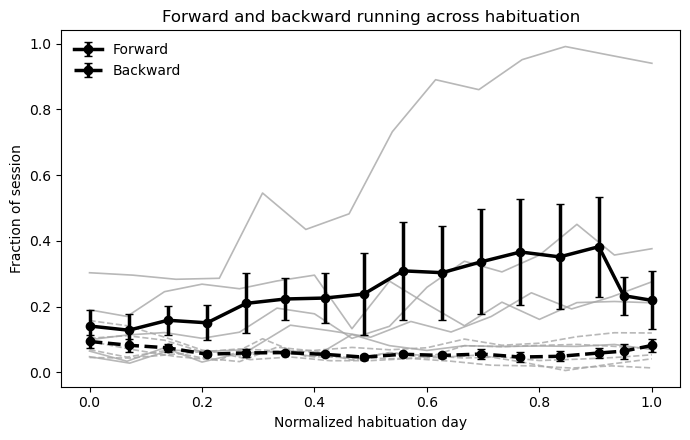

In [3]:
from src.vis.plots import plot_habituation_forward_backward

fig, ax, hab_fb_summary = plot_habituation_forward_backward(hab_session_df)

In [4]:
def make_habituation_direction_daybin_df(hab_session_df):
    """
    Make animal × day-bin × direction table for RM-ANOVA.
    """

    daybin_df = (
        hab_session_df
        .groupby(["animal", "phase_day_bin"], dropna=False)
        .agg(
            frac_forward=("frac_forward", "mean"),
            frac_backward=("frac_backward", "mean"),
            frac_stationary=("frac_stationary", "mean"),
            mean_speed_path_cms=("mean_speed_path_cms", "mean"),
            n_sessions=("date", "nunique"),
        )
        .reset_index()
    )

    long_df = daybin_df.melt(
        id_vars=["animal", "phase_day_bin", "n_sessions"],
        value_vars=["frac_forward", "frac_backward"],
        var_name="direction",
        value_name="frac_locomotor_state"
    )

    long_df["direction"] = long_df["direction"].replace({
        "frac_forward": "forward",
        "frac_backward": "backward",
    })

    long_df["phase_day_bin"] = pd.Categorical(
        long_df["phase_day_bin"],
        categories=["early", "middle", "late"],
        ordered=True
    )

    long_df["direction"] = pd.Categorical(
        long_df["direction"],
        categories=["backward", "forward"],
        ordered=True
    )

    return long_df

In [5]:
hab_direction_rm_df = make_habituation_direction_daybin_df(hab_session_df)

hab_direction_rm_df.groupby("animal").size().reset_index(name="n_cells")

,animal,n_cells
0,NML_04,6
1,NML_05,6
2,NML_06,6
3,NML_07,6
4,NML_08,6


In [6]:
from statsmodels.stats.anova import AnovaRM

aov_hab_direction = AnovaRM(
    data=hab_direction_rm_df,
    depvar="frac_locomotor_state",
    subject="animal",
    within=["phase_day_bin", "direction"]
).fit()

print(aov_hab_direction)

                       Anova
                        F Value Num DF Den DF Pr > F
----------------------------------------------------
phase_day_bin            3.1368 2.0000 8.0000 0.0987
direction                3.6664 1.0000 4.0000 0.1280
phase_day_bin:direction  3.0838 2.0000 8.0000 0.1017

